# LÝ THUYẾT: KIỂM ĐỊNH TÍNH DỪNG BẰNG ROLLING STATISTIC

## 1. Rolling Statistics (Thống kê trượt) là gì?
Rolling Statistics là kỹ thuật tính toán các đại lượng thống kê (như Trung bình, Độ lệch chuẩn) không phải trên toàn bộ tập dữ liệu cùng một lúc, mà tính trên một **cửa sổ thời gian (Window)** có kích thước cố định, trượt dần từ đầu đến cuối chuỗi dữ liệu.



**Công thức toán học (với cửa sổ kích thước $W$):**
* **Rolling Mean (Trung bình trượt) tại thời điểm $t$:**
  $$Mean_t = \frac{1}{W} \sum_{i=0}^{W-1} Y_{t-i}$$
* **Rolling STD (Độ lệch chuẩn trượt) tại thời điểm $t$:**
  $$STD_t = \sqrt{\frac{1}{W-1} \sum_{i=0}^{W-1} (Y_{t-i} - Mean_t)^2}$$

## 2. Tại sao phải dùng cửa sổ trượt (Window) thay vì tính toàn bộ?
* Nếu tính Mean/STD toàn bộ, ta chỉ thu được **1 con số tĩnh duy nhất** cho cả năm 2020. Con số này hoàn toàn vô nghĩa vì nó che lấp mọi sự biến động (lúc dịch bùng phát hay lúc êm đềm).
* **Lợi ích của Rolling:** Giúp ta theo dõi sự **thay đổi của các đại lượng thống kê theo thời gian thực**. Nó cho ta thấy cấu trúc động của dữ liệu, cho phép ta nhìn thấy Trend (qua Rolling Mean) và Volatility (Sự biến động/Rủi ro qua Rolling STD) qua từng giai đoạn ngắn hạn, trung hạn và dài hạn.

## 3. Ý nghĩa giá trị của Rolling Mean và Rolling STD
Giả sử ta xét cửa sổ $W = 7$ ngày:
* **Rolling Mean (Trung bình 7 ngày):**
  * *Lúc cao:* Cho thấy tuần đó đang là đỉnh dịch, số ca nhiễm/tử vong đang ở mức báo động.
  * *Lúc thấp:* Dịch bệnh đang được kiểm soát tốt, hoặc đang ở giai đoạn ủ bệnh.
* **Rolling STD (Độ lệch chuẩn 7 ngày):**
  * *Lúc cao:* Dữ liệu trong tuần đó cực kỳ hỗn loạn, trồi sụt thất thường (VD: Hôm nay 1000 ca, mai 50.000 ca, mốt lại 500 ca). Phản ánh sự mất ổn định hoặc hệ thống báo cáo có vấn đề.
  * *Lúc thấp:* Dữ liệu rất ổn định, dễ dự báo (ngày nào cũng đều đều mức đó).

## 4. Dấu hiệu của một Chuỗi dừng (Stationary Series) qua Rolling
Một chuỗi được kết luận là **Dừng (Stationary)** nếu khi ta vẽ biểu đồ:
1. Đường **Rolling Mean** là một đường nằm ngang song song với trục hoành (Kỳ vọng không đổi theo thời gian).
2. Đường **Rolling STD** cũng là một đường nằm ngang song song với trục hoành (Phương sai không đổi theo thời gian).
*Ngược lại, nếu các đường này có xu hướng dốc lên/chúi xuống hoặc uốn lượn liên tục, chuỗi đó là chuỗi Không dừng (Non-Stationary).*

[Time Series Mode] Đã nạp và sắp xếp dữ liệu theo 'Date'.
[EXECUTE] Đang vẽ Rolling MEAN cho biến 'Confirmed'...


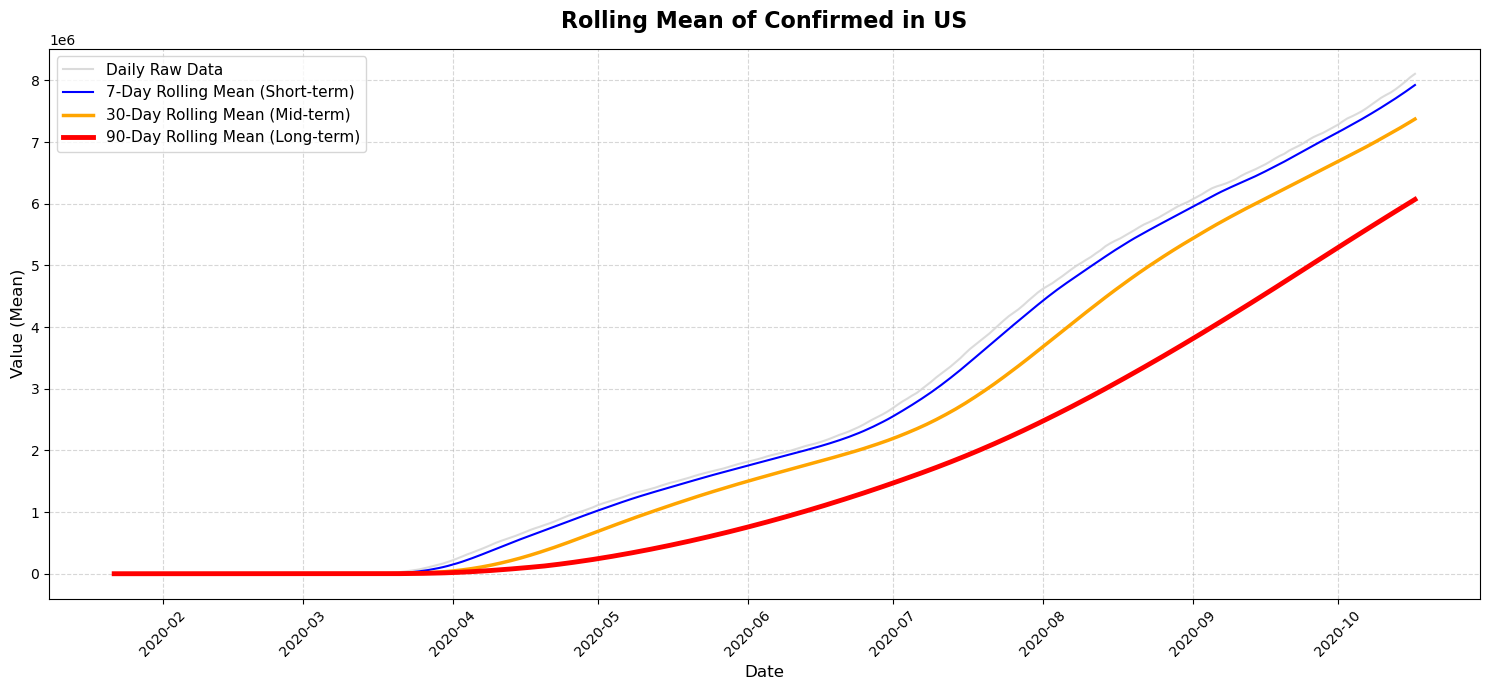

[EXECUTE] Đang vẽ Rolling STD cho biến 'Confirmed'...


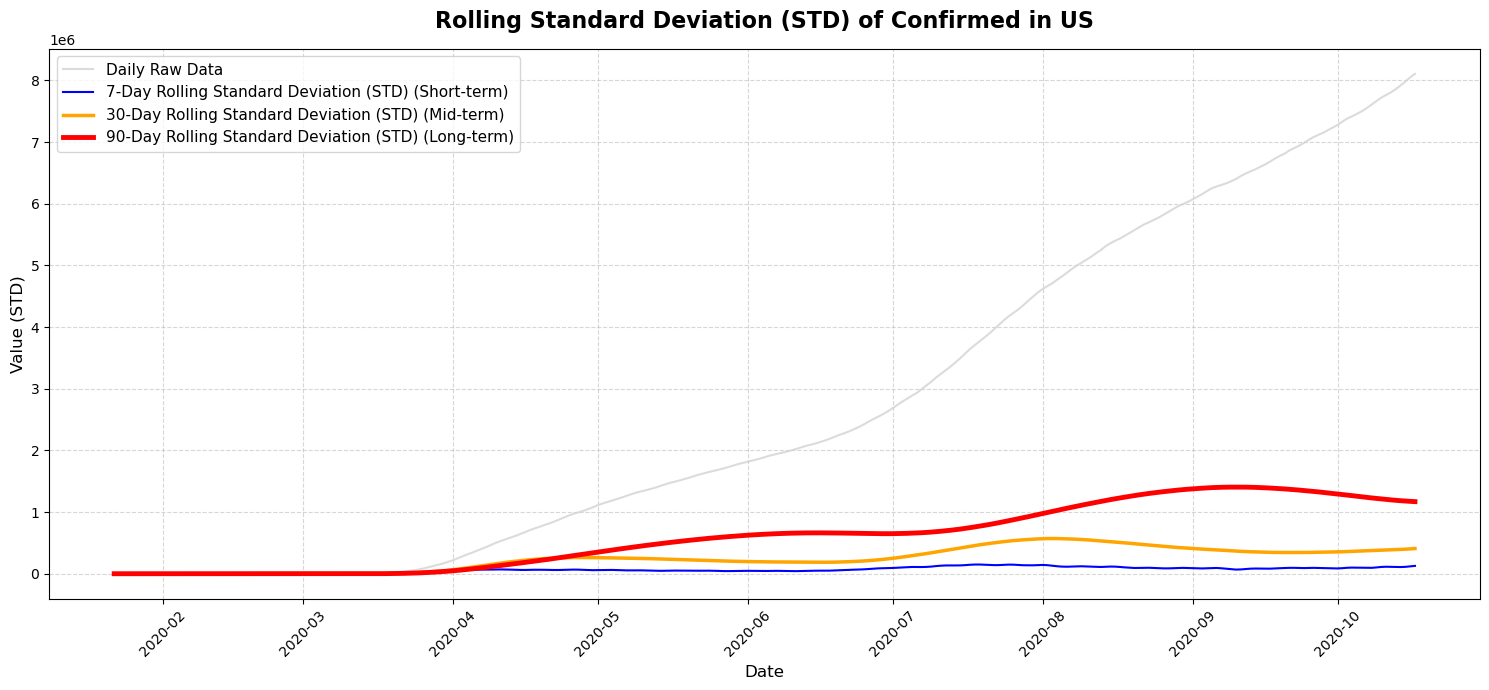

In [ ]:
import os
import sys

for src_path in (os.path.abspath("../src"), os.path.abspath("src")):
    if os.path.isdir(src_path) and src_path not in sys.path:
        sys.path.append(src_path)

from time_series.dataset import TimeSeriesDataset
from time_series.analysis_rolling_statistic import RollingStatisticAnalysis

ts_data = TimeSeriesDataset(path="../data/time_series/time-series-19-covid-combined.csv", time_column="Date")

# --- 1. VẼ ROLLING MEAN ---
mean_analyzer = RollingStatisticAnalysis(region="US", feature_name="Confirmed", stat_type="Mean")
mean_analyzer.run(ts_data)

# --- 2. VẼ ROLLING STD ---
std_analyzer = RollingStatisticAnalysis(region="US", feature_name="Confirmed", stat_type="STD")
std_analyzer.run(ts_data)

## Phân tích và nhận xét tính dừng (Stationarity) qua Rolling Statistics

Dựa vào hai biểu đồ Rolling Mean và Rolling STD của biến `Confirmed` tại Mỹ, ta tiến hành giải đáp các câu hỏi để kiểm định tính dừng của chuỗi dữ liệu:

### 5.1. Phân tích kỳ vọng (Rolling Mean)
* **Số ca Covid có tăng/giảm theo thời gian không?** Số liệu gốc (Raw Data) tăng trưởng liên tục.
* **Các đường Mean (7, 30, 90) có tăng hay giảm?** Cả 3 đường Rolling Mean đều hướng tăng, song hành cùng đường dữ liệu gốc. Không có bất kỳ đoạn nào biểu đồ đi ngang hay chúc xuống.
* **So sánh Mean 7, 30 và 90 (Ngắn hạn vs Dài hạn):**
    * **Mean 7 (Ngắn hạn):** Cực kỳ nhạy cảm, bám sát và gần như chồng khít lên đường dữ liệu gốc. Nó phản ánh chính xác xu hướng tức thời.
    * **Mean 30 (Trung hạn):** Có độ trễ nhất định, nằm thấp hơn đường gốc một chút do phải lấy trung bình kéo lùi về 30 ngày trước.
    * **Mean 90 (Dài hạn):** Đường màu đỏ mượt nhất nhưng lại nằm thấp nhất và có độ trễ lớn nhất. Do cửa sổ quá rộng (3 tháng), nó bị "kéo ghì" lại bởi những con số thấp của quá khứ, khiến nó không phản ứng kịp với tốc độ bùng dịch hiện tại.
* **Kết luận kỳ vọng:** Mean thay đổi (tăng) liên tục theo thời gian $\rightarrow$ **Dấu hiệu thứ nhất của chuỗi KHÔNG DỪNG.**

### 5.2. Phân tích Độ biến động (Rolling STD)
* **Độ lệch chuẩn rolling có ổn định không?** Hoàn toàn KHÔNG ổn định. 
    * Ở giai đoạn đầu (Tháng 1 - Tháng 3), STD gần như bằng 0 do số ca bệnh còn rất ít và đi ngang.
    * Nhưng từ Tháng 4 trở đi, độ biến động bắt đầu phình to. Đặc biệt nhìn vào đường **90-Day STD (màu đỏ)**, ta thấy nó uốn lượn thành một ngọn đồi, đạt đỉnh vào tầm Tháng 8 - Tháng 9. Điều này chứng tỏ dữ liệu trong khoảng thời gian này trồi sụt và chênh lệch cực kỳ khủng khiếp so với giá trị trung bình của nó.
* **Kết luận phương sai:** STD biến thiên mạnh mẽ theo thời gian $\rightarrow$ **Dấu hiệu thứ hai của chuỗi KHÔNG DỪNG.**

### 5.3. Các đỉnh bùng phát và Kết luận chung
* **Các đỉnh có rõ không? Có nhiều đợt bùng phát không?** Nhìn vào Rolling Mean, ta chỉ thấy một con dốc tăng cao. Nhưng khi nhìn vào **Rolling STD**, các đợt bùng phát lộ diện rõ ràng. Cứ mỗi lần dịch bùng mạnh (gia tăng tốc độ lây nhiễm), khoảng cách giữa các số liệu trong cửa sổ bị kéo giãn ra, làm STD vọt lên tạo thành các đỉnh (rõ nhất là đợt sóng mùa hè T7-T9).
* **KẾT LUẬN CUỐI CÙNG VỀ TÍNH DỪNG:**
    * Thỏa mãn cả 2 điều kiện: Kỳ vọng (Mean) thay đổi và Phương sai (STD) không ổn định. Ta kết luận chắc chắn 100%: **Chuỗi dữ liệu tích lũy Covid-19 là một chuỗi KHÔNG DỪNG (Non-stationary).** 
    * Để có thể sử dụng các mô hình dự báo như ARIMA, ta bắt buộc phải tiến hành bước Tiền xử lý quan trọng: **Lấy sai phân (Differencing)** để triệt tiêu đi cái Trend tăng liên tục này, ép biểu đồ Mean và STD về dạng các đường nằm ngang ổn định.